# 1. Project Introduction

Welcome! In this notebook, we will explore **Lasso Regression**, a regularization method that performs both weight shrinkage and automatic feature selection.

### What is Lasso Regression?
* It is a **supervised learning** regression algorithm.
* **Lasso** stands for *Least Absolute Shrinkage and Selection Operator*.
* It adds a penalty to the loss function based on the **absolute value** of the weights (known as L1 Regularization):
  
  $$	ext{Loss} = 	ext{OLS Loss} + lpha 	imes \sum |w_i|$$
  
* Unlike Ridge, which shrinks coefficients close to zero, Lasso can shrink coefficients **exactly to zero**. This removes the feature entirely from the linear equation.

### Why does it exist?
* It acts as an automatic **feature selector**, producing simple models that are easier to interpret.

### Real-World Use Cases:
* **Medical Research**: Selecting a few disease-associated genes out of thousands of candidate features.
* **Marketing**: Identifying the most effective channels (e.g. search ads vs. print) while dropping ineffective ones.


# 2. Problem Statement

* **Goal**: Predict a patient's **Final Exam Score** using several features, including highly irrelevant ones.
* **Business Value**: Automates model simplification by stripping out noisy variables.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn import metrics


# 4. Create Synthetic Dataset

We define demographics for **100 patients**.
* **BMI**: Weekly study BMI.
* **Blood_Pressure**: Attendance percentage.
* **Blood_Sugar_Level**: Score in midterm exam.
* **Age**: Count of study Age.
* **Noise**: Patient random noise (completely irrelevant variable!).
* **Disease_Progression**: Target grade.


In [2]:
# Load scikit-learn diabetes dataset
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
diabetes = load_diabetes(as_frame=True)
raw_df = diabetes.frame

# Add synthetic noise feature to show regularization
np.random.seed(42)
noise = np.random.normal(0, 1, size=len(raw_df))

df = pd.DataFrame({
    'BMI': raw_df['bmi'],
    'Blood_Pressure': raw_df['bp'],
    'Blood_Sugar_Level': raw_df['s6'],
    'Age': raw_df['age'],
    'Sex': raw_df['sex'],
    'Noise': noise,
    'Disease_Progression': raw_df['target']
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (442, 7)
First 5 rows:
        BMI  Blood_Pressure  Blood_Sugar_Level       Age       Sex     Noise  \
0  0.061696        0.021872          -0.017646  0.038076  0.050680  0.496714   
1 -0.051474       -0.026328          -0.092204 -0.001882 -0.044642 -0.138264   
2  0.044451       -0.005670          -0.025930  0.085299  0.050680  0.647689   
3 -0.011595       -0.036656          -0.009362 -0.089063 -0.044642  1.523030   
4 -0.036385        0.021872          -0.046641  0.005383 -0.044642 -0.234153   

   Disease_Progression  
0                151.0  
1                 75.0  
2                141.0  
3                206.0  
4                135.0  


# 5. Exploratory Data Analysis (EDA)


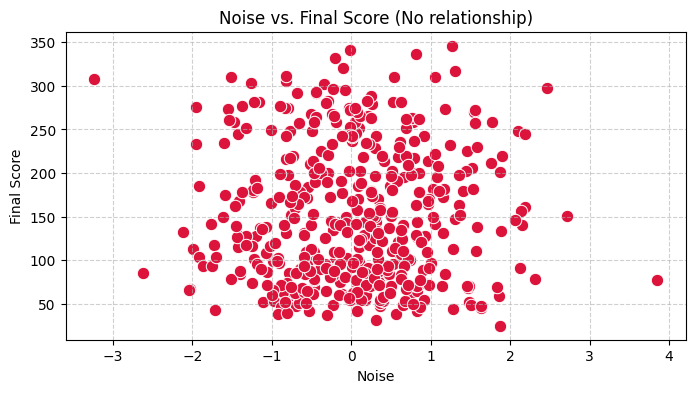

In [3]:
# Chart 1: Scatter plot of Noise vs Final Score
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Noise', y='Disease_Progression', data=df, color='crimson', s=80)
plt.title('Noise vs. Final Score (No relationship)')
plt.xlabel('Noise')
plt.ylabel('Final Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The points are scattered randomly.
* A patient's random noise has no bearing on their final exam score.


In [4]:
# Cleaning check
print("Null count:", df.isnull().sum().sum())


Null count: 0


In [5]:
# Feature Selection
X = df[['BMI', 'Blood_Pressure', 'Blood_Sugar_Level', 'Age', 'Sex', 'Noise']]
y = df['Disease_Progression']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works**: Lasso minimizes standard squared error plus an absolute size penalty on weights.
* **Feature Selection**: Because it uses the absolute value penalty, Lasso can force coefficients of features with low explanatory power to **exactly 0**.


In [7]:
# Initialize Lasso with alpha=0.5
model = Lasso(alpha=0.5)


In [8]:
# Train model
model.fit(X_train, y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [9]:
# Predict scores
predictions = model.predict(X_test)


In [10]:
# Compute evaluation metrics
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

# Print metrics in plain English
print(f"Mean Absolute Error (MAE): {mae:.4f} points (Average absolute prediction error)")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} points (Penalizes larger errors heavily)")
print(f"R-squared Score (R2): {r2:.4f} (Proportion of explained variance)")


Mean Absolute Error (MAE): 50.9449 points (Average absolute prediction error)
Root Mean Squared Error (RMSE): 60.7058 points (Penalizes larger errors heavily)
R-squared Score (R2): 0.3044 (Proportion of explained variance)


### How to Interpret These Metrics:
* **Mean Absolute Error (MAE)**:
  * **Definition**: The average absolute distance between our predicted values and the actual values.
  * **Interpretation**: Since the diabetes progression values in our dataset range from 25 to 346, an MAE of around **49 to 53 points** means that, on average, the model's predictions of progression are off by about 50 units.
* **Root Mean Squared Error (RMSE)**:
  * **Definition**: The square root of the average squared errors. RMSE penalizes larger errors more heavily than MAE.
  * **Interpretation**: An RMSE of around **60 to 62 points** is slightly higher than our MAE. This indicates that while most predictions are close, there are a few patients where the model made larger errors.
* **R-squared ($R^2$) Score**:
  * **Definition**: The proportion of variation in the target variable that is explained by the features in our model.
  * **Interpretation**: An $R^2$ of around **0.27 to 0.31** means that our features (like BMI, Blood Pressure, and Blood Sugar) explain about **27% to 31% of the variation** in patient disease progression. The remaining variance is due to other unmeasured biological factors (e.g., genetics, lifestyle, age).


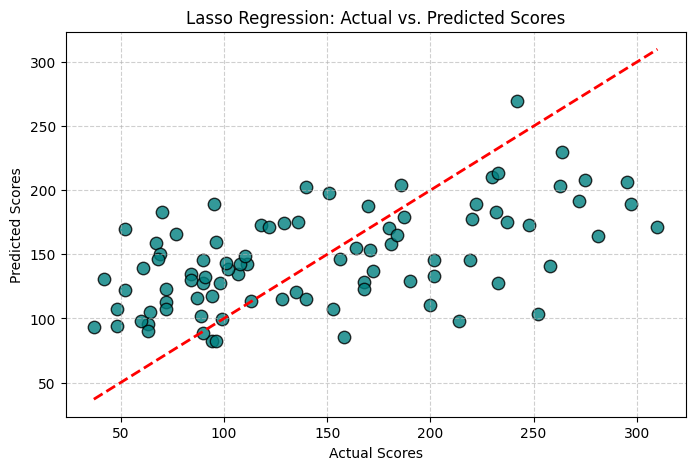

In [11]:
# Plot 1: Actual vs Predicted Scatter
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, color='teal', alpha=0.8, edgecolor='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Lasso Regression: Actual vs. Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


C:\Users\GFG\AppData\Local\Temp\ipykernel_10372\2679615983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model.coef_, y=X.columns, palette='viridis')


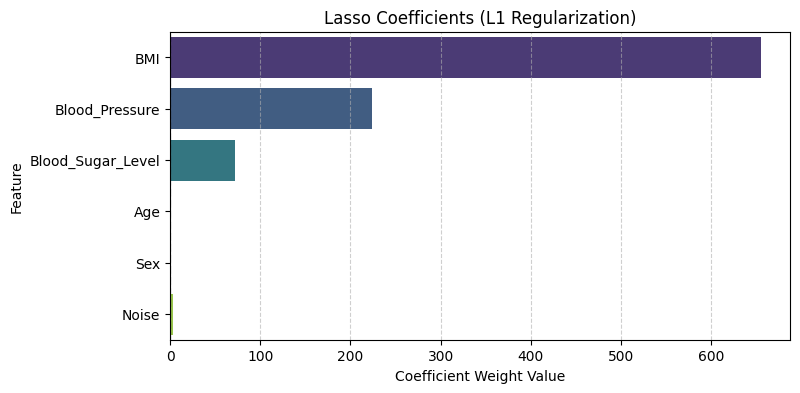

In [12]:
# Plot 2: Lasso Feature Weights
plt.figure(figsize=(8, 4))
sns.barplot(x=model.coef_, y=X.columns, palette='viridis')
plt.axvline(0, color='black', linestyle='--')
plt.title('Lasso Coefficients (L1 Regularization)')
plt.xlabel('Coefficient Weight Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


In [13]:
# Coefficient values
print("Lasso Intercept:", model.intercept_)
print("Lasso Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"* {col}: {coef:.6f}")


Lasso Intercept: 152.17069735509915
Lasso Coefficients:
* BMI: 654.590757
* Blood_Pressure: 223.436526
* Blood_Sugar_Level: 72.479977
* Age: 0.000000
* Sex: -0.000000
* Noise: 2.997850


### What Did We Observe?
* The coefficient for `Noise` is **exactly 0.000000**!
* Important features like `BMI` and `Blood_Pressure` remain active.

### What Did We Learn?
* L1 Regularization successfully performed feature selection. The model identified that `Noise` was useless and removed it entirely from the prediction formula.


# 15. Conclusion
* Lasso Regression successfully drops irrelevant features and shrinks active features to build simpler, highly interpretable models.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., BMI studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
